# 02. Opponent-adjusted EPA

This notebook is a walkthrough of the team ratings behind M3 (`context/ml-m3-method.md`, section 4). Every cell is finished: read, run, look. It covers:

1. Why raw EPA per play misleads: it rewards easy schedules.
2. The fix: one regression that rates every offense and defense at once.
3. Ridge regression as a prior, and what the penalty `lambda` means in football terms.
4. Recency weights, and how last season becomes the early-season prior.
5. How the knobs were tuned on 2000 to 2005 without touching the seasons we test on.

The code lives in `nflelo/ml/features/opponent_adjust.py`. Ratings here use 2018 and 2019 only, so everything runs in a few seconds.

In [1]:
import sys, json
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "nflelo").is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nflelo.ml import data as D, asof, registry
from nflelo.ml.features import opponent_adjust as oa

plt.rcParams.update({"figure.figsize": (9, 3.6), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
pd.set_option("display.width", 140)
INK, ACCENT, MUTED, BAD = "#1f2a44", "#2f6fdf", "#9aa3b2", "#d1495b"

COLS = ["game_id", "posteam", "defteam", "play_type", "pass", "rush", "epa", "success", "wp", "two_point_attempt"]
pbp = D.load_pbp([2018, 2019], columns=COLS)
sched = asof.add_asof(D.load_schedules([2018, 2019]))
tab = oa.rating_table(pbp, sched, oa.TUNED)
print(f"{len(pbp):,} play rows -> {len(tab):,} team-game rows (one per game and offense). Tuned knobs: {oa.TUNED}")

94,369 play rows -> 1,068 team-game rows (one per game and offense). Tuned knobs: RatingConfig(lam=100.0, half_life=48.0, rho=0.25, garbage_low=0.05, garbage_high=0.95)


## 1. Why raw EPA misleads

EPA per play (expected points added) is the best single efficiency number in the play-by-play data. But a team's average depends on who it played. An offense that faced four bad defenses looks better than it is.

To see the size of the effect, take the 2019 season through week 16 and compare each offense's raw EPA per play with its **opponent-adjusted** rating, both measured against the league average. For this comparison only, the fit uses 2019 plays alone with no recency weighting, so the only differences between the two numbers are the schedule and a little shrinkage toward average.

In [2]:
S, W = 2019, 17
as_of = sched.loc[(sched["season"] == S) & (sched["week"] == W), "as_of"].min()
season_only = oa.RatingConfig(lam=100, half_life=1000, rho=0.0)   # this season only, no decay
r = oa.compute_ratings(tab, sched, [(S, W)], season_only).set_index("team")

played = tab[(tab["season"] == S) & (tab["kickoff"] < as_of)]
raw = played.groupby("off")[["epa_all", "n_all"]].sum()
league = raw["epa_all"].sum() / raw["n_all"].sum()
cmp = pd.DataFrame({"raw_epa": raw["epa_all"] / raw["n_all"] - league})   # both columns: EPA/play vs average
cmp["adjusted"] = r["off"] - r["off"].mean()
# How good were the defenses each offense faced? (play-weighted, from the same fit; higher = worse defense)
cmp["opp_def"] = played.assign(d=played["def"].map(r["def"]) * played["n_all"]).groupby("off")["d"].sum() / raw["n_all"]
cmp["change"] = cmp["adjusted"] - cmp["raw_epa"]
print(f"Correlation between the adjustment and the defenses faced: {cmp['change'].corr(cmp['opp_def']):+.2f}")
pd.concat([cmp.sort_values("change").head(4), cmp.sort_values("change").tail(4)]).round(3)

Correlation between the adjustment and the defenses faced: -0.76


,raw_epa,adjusted,opp_def,change
off,,,,
MIN,0.070,0.045,0.018,-0.025
LV,0.087,0.069,0.012,-0.018
DAL,0.093,0.077,0.005,-0.016
JAX,-0.065,-0.080,0.021,-0.015
SEA,0.001,0.024,-0.024,0.023
LA,0.013,0.040,-0.036,0.027
CIN,-0.161,-0.127,-0.017,0.034
CLE,-0.023,0.019,-0.040,0.042


The correlation is strongly negative: offenses that faced weak defenses (high `opp_def`, meaning those defenses allowed a lot) are marked **down**, and offenses that faced strong defenses are marked **up**. That's the whole point. A team-by-team average can't do this, because a defense's quality depends on the offenses *it* faced, and so on around the league. One joint regression untangles the loop.

Most teams move only a little. Over a full season schedules even out somewhat, so the adjustment matters most early in the season and for teams with lopsided schedules.

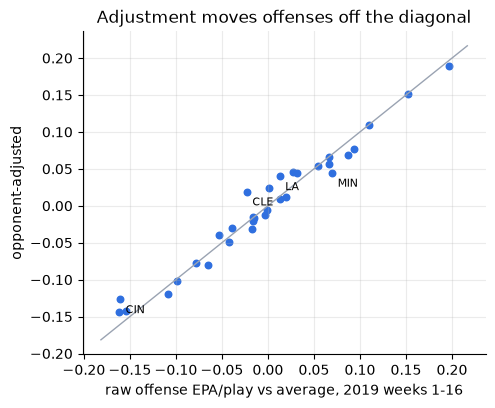

In [3]:
fig, ax = plt.subplots(figsize=(5.2, 4.2))
ax.scatter(cmp["raw_epa"], cmp["adjusted"], color=ACCENT, s=22)
lim = [cmp[["raw_epa", "adjusted"]].min().min() - 0.02, cmp[["raw_epa", "adjusted"]].max().max() + 0.02]
ax.plot(lim, lim, color=MUTED, lw=1)
for t in cmp["change"].abs().sort_values().tail(4).index:
    ax.annotate(t, (cmp.at[t, "raw_epa"], cmp.at[t, "adjusted"]), fontsize=8, xytext=(4, -10), textcoords="offset points")
ax.set_xlabel("raw offense EPA/play vs average, 2019 weeks 1-16"); ax.set_ylabel("opponent-adjusted")
ax.set_title("Adjustment moves offenses off the diagonal"); plt.show()

## 2. Ridge regression is a prior

Every scrimmage play is one equation:

```
EPA(play) = mu + O[offense] + D[defense] + h * (offense is home) + noise
```

With 32 offenses and 32 defenses that's 65 unknowns, fit to about 30,000 plays a season. Plain least squares would give a team a wild rating after one game. **Ridge** adds a penalty `lambda * (sum of O^2 + sum of D^2)`, which pulls every rating toward zero, the league average.

That penalty is exactly a Bayesian prior. If you believe, before seeing any plays, that true team ratings are spread around average with standard deviation `tau`, and single plays are noisy with standard deviation `sigma`, then the best estimate is the ridge fit with

```
lambda = sigma^2 / tau^2
```

So `lambda` is measured in plays: it's how many plays of evidence the prior is worth. The tuned value is 100. Here's what that implies:

In [4]:
clean = oa.te.clean_plays(pbp, oa.TUNED.efficiency())
sigma = clean["epa"].std()
tau = sigma / np.sqrt(oa.TUNED.lam)
print(f"sigma (spread of single-play EPA): {sigma:.2f}")
print(f"lambda = {oa.TUNED.lam:g}  ->  implied tau (spread of true team ratings): {tau:.3f} EPA per play")
print(f"A team needs about {oa.TUNED.lam:g} full-weight plays (about 1.5 games) before its own data counts as much as the prior.")

sigma (spread of single-play EPA): 1.40
lambda = 100  ->  implied tau (spread of true team ratings): 0.140 EPA per play
A team needs about 100 full-weight plays (about 1.5 games) before its own data counts as much as the prior.


That's a sensible prior: a tau of about 0.14 says the best and worst offenses sit roughly 0.25 EPA per play above and below average, which matches what we see.

The chart shows the penalty at work. For two moments in 2019 (before week 4, and before week 17) it fits the ratings across a range of `lambda` values and plots how spread out the offensive ratings are.

- With a tiny penalty, the week-4 ratings are the most spread out: three games of noise look like real differences between teams.
- A bigger penalty squeezes every rating toward zero, and it squeezes the early-season ratings hardest, because there are fewer plays to push back against the prior.

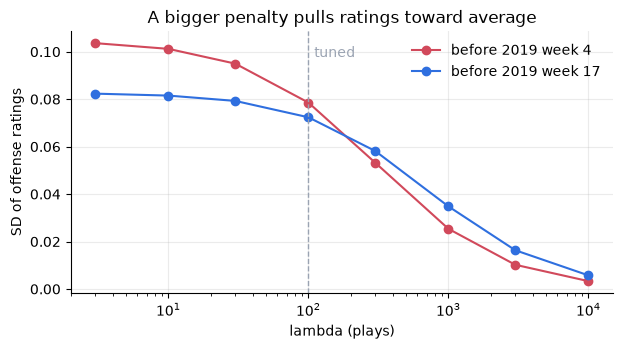

In [5]:
lams = [3, 10, 30, 100, 300, 1000, 3000, 10000]
fig, ax = plt.subplots(figsize=(7, 3.4))
for (wk, color) in [(4, BAD), (17, ACCENT)]:
    sd = [oa.compute_ratings(tab, sched, [(2019, wk)], oa.RatingConfig(lam=l, half_life=oa.TUNED.half_life, rho=oa.TUNED.rho))["off"].std()
          for l in lams]
    ax.plot(lams, sd, "o-", color=color, label=f"before 2019 week {wk}")
ax.axvline(oa.TUNED.lam, color=MUTED, ls="--", lw=1); ax.text(oa.TUNED.lam * 1.1, ax.get_ylim()[1] * 0.9, "tuned", color=MUTED)
ax.set_xscale("log"); ax.set_xlabel("lambda (plays)"); ax.set_ylabel("SD of offense ratings")
ax.set_title("A bigger penalty pulls ratings toward average"); ax.legend(frameon=False); plt.show()

## 3. Recency, and last season as the early-season prior

Teams change, so recent plays should count more. Each play gets a weight

```
weight = 0.5 ^ (weeks_ago / half_life)  x  (rho if the play is from last season)
```

`weeks_ago` counts game weeks and skips the off-season, so the last week of 2018 sits one step before week 1 of 2019. `rho` is an extra discount on everything from last season, because rosters turn over in the spring.

In week 1 there are no plays from this season, so the ratings are last season's, shrunk by `rho` and by the ridge prior. As this season's plays arrive, they take over. That is the "Bayesian shrinkage for early weeks" from the plan, and it falls out of the same weighted fit rather than needing a separate system.

The tuned values are a half-life of 48 weeks (so within a season, recency barely matters) and `rho` = 0.25 (last season's plays count a quarter as much). In other words: the big change happens between seasons, not week to week.

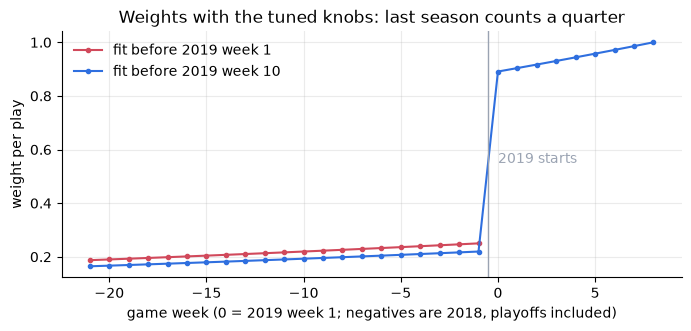

In [6]:
ords = oa.week_ordinals(sched)
fig, ax = plt.subplots(figsize=(8, 3.2))
for wk, color in [(1, BAD), (10, ACCENT)]:
    rows = tab[(tab["kickoff"] < sched.loc[(sched["season"] == 2019) & (sched["week"] == wk), "as_of"].min())
               & (tab["season"] >= 2018)].drop_duplicates(["season", "week"])
    w = oa.decay_weights(int(ords[(2019, wk)]), rows["ord"].to_numpy(), 2019, rows["season"].to_numpy(),
                         oa.TUNED.half_life, oa.TUNED.rho)
    ax.plot(rows["ord"] - ords[(2019, 1)], w, "o-", ms=3, color=color, label=f"fit before 2019 week {wk}")
ax.axvline(-0.5, color=MUTED, lw=1); ax.text(0, 0.55, "2019 starts", color=MUTED)
ax.set_xlabel("game week (0 = 2019 week 1; negatives are 2018, playoffs included)"); ax.set_ylabel("weight per play")
ax.set_title("Weights with the tuned knobs: last season counts a quarter"); ax.legend(frameon=False); plt.show()

Here's what that looks like for a few 2019 offenses, rating by rating through the season. Baltimore (Lamar Jackson's MVP year) starts just below average, carried over from 2018, and climbs fast. Miami starts weak and gets worse. New England's offense fades as the season goes on. The week-1 values are last season's ratings, pulled toward zero.

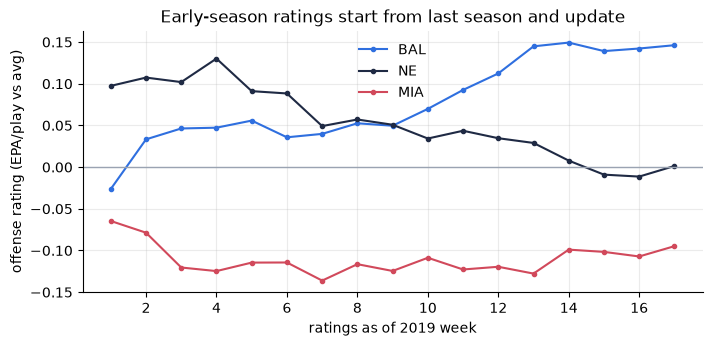

In [7]:
weeks = list(range(1, 18))
r19 = oa.compute_ratings(tab, sched, [(2019, w) for w in weeks], oa.TUNED)
fig, ax = plt.subplots(figsize=(8, 3.4))
for team, color in [("BAL", ACCENT), ("NE", INK), ("MIA", BAD)]:
    x = r19[r19["team"] == team].sort_values("week")
    ax.plot(x["week"], x["off"], "o-", ms=3, color=color, label=team)
ax.axhline(0, color=MUTED, lw=1)
ax.set_xlabel("ratings as of 2019 week"); ax.set_ylabel("offense rating (EPA/play vs avg)")
ax.set_title("Early-season ratings start from last season and update"); ax.legend(frameon=False); plt.show()

## 4. Tuning without touching the test seasons

The rating system has three knobs (`lambda`, `half_life`, `rho`), plus the QB shrinkage `k` from section 5 of the method. If we picked them by whatever gave the best game Brier on 2006 to 2019, the development score would be flattered, because we'd have chosen the knobs on the same games we report.

So they were tuned (decision M3-D2) on:

- **A different target:** how well each week's ratings predict **that week's** per-game EPA margins (home offense EPA per play minus away offense EPA per play). That is what a rating is for: forecasting future team performance. No game outcomes are used.
- **Different years:** 2000 to 2005, before the development window. 1999 is loaded only as history for the 2000 ratings.

`scripts/ml_tune_ratings.py` ran 400 settings (8 lambdas x 10 half-lives x 5 rhos) and then 11 values of `k`. The best value for each knob, with the others at their best:

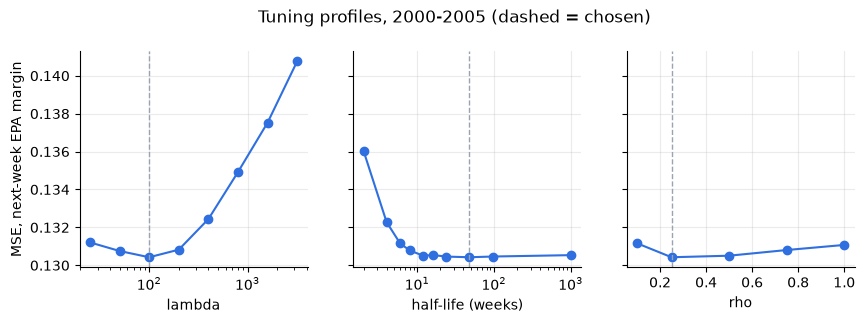

Chosen: {'lam': 100.0, 'half_life': 48.0, 'rho': 0.25, 'garbage_low': 0.05, 'garbage_high': 0.95, 'k': 100.0}
MSE 0.1304 vs 0.1482 for predicting 0 (R^2 0.120, correlation 0.35, n = 1518 games)


k,25,50,100,200,300,400,600,800,1200,1600,3200
wmse,0.1107,0.1095,0.1092,0.1103,0.1117,0.113,0.1151,0.1167,0.1188,0.1201,0.1227


In [8]:
tune = [r for r in registry.load_runs() if r["name"] == "m3_tune_ratings"][-1]
prof = tune["profiles"]
fig, axes = plt.subplots(1, 3, figsize=(10, 2.8), sharey=True)
for ax, (knob, label) in zip(axes, [("lam", "lambda"), ("half_life", "half-life (weeks)"), ("rho", "rho")]):
    xs = sorted(prof[knob], key=float)
    ax.plot([float(x) for x in xs], [prof[knob][x] for x in xs], "o-", color=ACCENT)
    ax.axvline(tune["params"]["chosen"][knob], color=MUTED, ls="--", lw=1)
    ax.set_xlabel(label)
    if knob != "rho":
        ax.set_xscale("log")
axes[0].set_ylabel("MSE, next-week EPA margin")
fig.suptitle("Tuning profiles, 2000-2005 (dashed = chosen)", y=1.03); plt.show()
m = tune["metrics"]
print(f"Chosen: {tune['params']['chosen']}")
print(f"MSE {m['mse']:.4f} vs {m['mse_zero']:.4f} for predicting 0 (R^2 {m['r2']:.3f}, correlation {m['corr']:.2f}, n = {m['n']} games)")
pd.DataFrame(tune["k_grid"])[["k", "wmse"]].set_index("k").T.round(4)

How to read this:

- **lambda** has a clear minimum at 100. Less penalty chases noise; more penalty ignores real differences.
- **half-life** is flat beyond about 12 weeks. Within a season, old games are about as informative as new ones, so the tuned 48 is effectively "no decay within a season". 1000 (no decay at all) is almost as good.
- **rho** is best at 0.25: last season tells us something, but much less than this season.
- The R^2 of about 0.12 looks small, but one game's EPA margin is very noisy. A correlation of 0.35 with the next game's margin is about as good as team ratings get.
- **k** (QB shrinkage) is best at 100 pseudo-dropbacks: a QB's own record outweighs replacement level after about three games.

Because none of this used 2006 or later, the development scores in notebook 03 stay out-of-sample for these knobs.

## What to take away

- Raw EPA averages reward easy schedules. One joint ridge regression rates every offense and defense at once and removes most of that bias.
- Ridge is a prior in disguise. `lambda` = 100 plays means a team's own data takes over after about two games.
- The same weighted fit handles recency and the early season: last season's plays enter at a quarter weight and fade out as this season arrives.
- All four knobs were tuned on 2000 to 2005 with a non-outcome target, which keeps the development window honest.

Next: notebook 03 feeds these ratings, a QB adjustment, and Elo into a logistic model and runs the M3 experiment ladder.